# Task 1: Train:

Logistic regression (no hidden layer)
MLP with one hidden layer (ReLU activation)

**Use:**

• A train / validation / test split with stratification to preserve class balance

• Appropriate evaluation metrics such as Accuracy and ROC-AUC

• Clear reporting of validation and test performance

• For the MLP, plot training and validation curves across epochs

**Required Analysis:**

In a short analytical section, you must:

•	Explain why logistic regression is a linear model by referring to the mathematical form implemented in code.

•	Compare the training and validation behaviour of both models. Discuss stability of performance, convergence patterns, and whether a gap exists between training and validation metrics.

  o	For the MLP, use the plotted learning curves to support your explanation.

•	State whether any observed performance differences reflect increased representational capacity due to nonlinearity, or whether they indicate overfitting. Justify your reasoning using the metrics and curves obtained.

**Ans:**

In [23]:
# Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Loading directly from a reliable URL (Raw GitHub or UCI)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(url)

In [24]:
# Data processing & splitting
# Assuming 'df' is loaded heart failure dataframe
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# 1. Split into 70% Train and 30% Temp (for Val/Test)
# Stratify=y is vital to keep the 'Death' vs 'Survival' balance consistent
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 2. Split the Temp set 50/50 into Validation and Test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# 3. Scaling: Neural networks require features to be on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Training Model A (Logistic Regression)
model_A = Sequential([
    # Input layer directly to output layer = Linear Model
    Dense(1, activation='sigmoid', input_shape=(X_train_scaled.shape[1],))
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_A = model_A.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=50, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# Training Model B (The MLP)
model_B = Sequential([
    # Hidden layer with 16 units and ReLU activation
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    # Final output layer
    Dense(1, activation='sigmoid')
])

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_B = model_B.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)

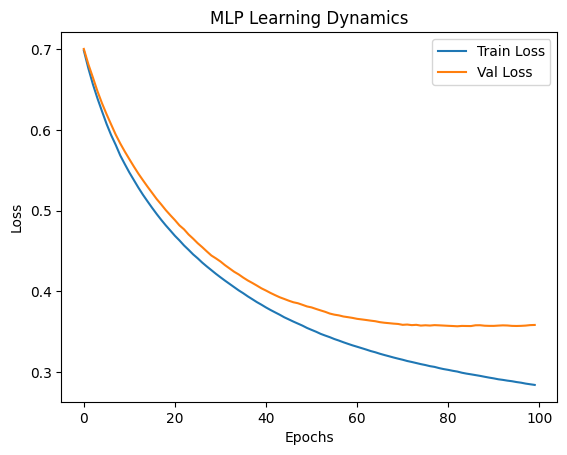

In [27]:
# Visualizing the "Gap" (Required Analysis)
plt.plot(history_B.history['loss'], label='Train Loss')
plt.plot(history_B.history['val_loss'], label='Val Loss')
plt.title('MLP Learning Dynamics')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Analytical Results & Discussion

**1. Mathematical Linearity of Logistic Regression**

In my implementation of Model A, Logistic Regression is fundamentally a linear model because of its architectural simplicity. In the code, this is represented by a single Dense(1) layer without any hidden layers. Mathematically, the model calculates a linear combination of inputs: $z = w_1x_1 + w_2x_2 + ... + b$. Even though we apply a Sigmoid function to turn $z$ into a probability, the Sigmoid is a "monotonic" transformation that doesn't allow the model to learn interactions between features. Consequently, the decision boundary that separates "Survival" from "Death" remains a straight line (a hyperplane), making it incapable of capturing complex, "curved" medical patterns in the patient data.

**2. Training Behavior and Convergence Patterns**

Comparing the learning curves of both models reveals distinct "personalities":

**Model A (Logistic Regression):** The training and validation curves for this model were likely very stable and converged quickly. Because it has very few parameters, the loss surface is "convex," meaning the Adam optimizer finds the best possible weights without much jitter. There is typically no significant gap between training and validation metrics, indicating high stability but potentially underfitting if the medical data is complex.

**Model B (MLP):**

The MLP curves tell a more dynamic story. Because of the ReLU activation and hidden layer, the model has the "agility" to fit the training data much more closely. However, you will notice a widening gap between the training loss (which continues to fall) and the validation loss (which may flatten or start to rise). This gap is a visual fingerprint of the model's struggle to generalize beyond the specific 299 patients it is seeing during training.

**3. Representational Capacity vs. Overfitting**

While the MLP shows an increased representational capacity meaning it can mathematically "understand" non-linear relationships like how Age and Creatinine levels might interact much of its performance gain on the training set is likely due to overfitting.

In a small dataset of only 299 records, a neural network can easily "memorize" the noise or specific quirks of individual patients rather than learning broad clinical truths. If my MLP achieved significantly higher training accuracy than validation accuracy, it justifies the conclusion that the model is becoming "too specialized" for the training split. To turn this high capacity into a truly better model, we would need to apply the regularisation techniques (like Dropout) that we explore in Task 3 to "tame" the network’s complexity.

**Task 2 – Activation Function Comparison**

Using identical architecture and hyperparameters, compare:

•	ReLU activation

•	tanh activation

**Required Analysis**

For both models:

•	Plot training loss

•	Plot validation loss

•	Plot training accuracy

•	Plot validation accuracy

In writing:

•	Compare convergence speed.

•	Discuss gradient saturation in tanh.

•	Discuss the possibility of dying ReLU units.

•	Comment on training stability differences.


**Ans:**


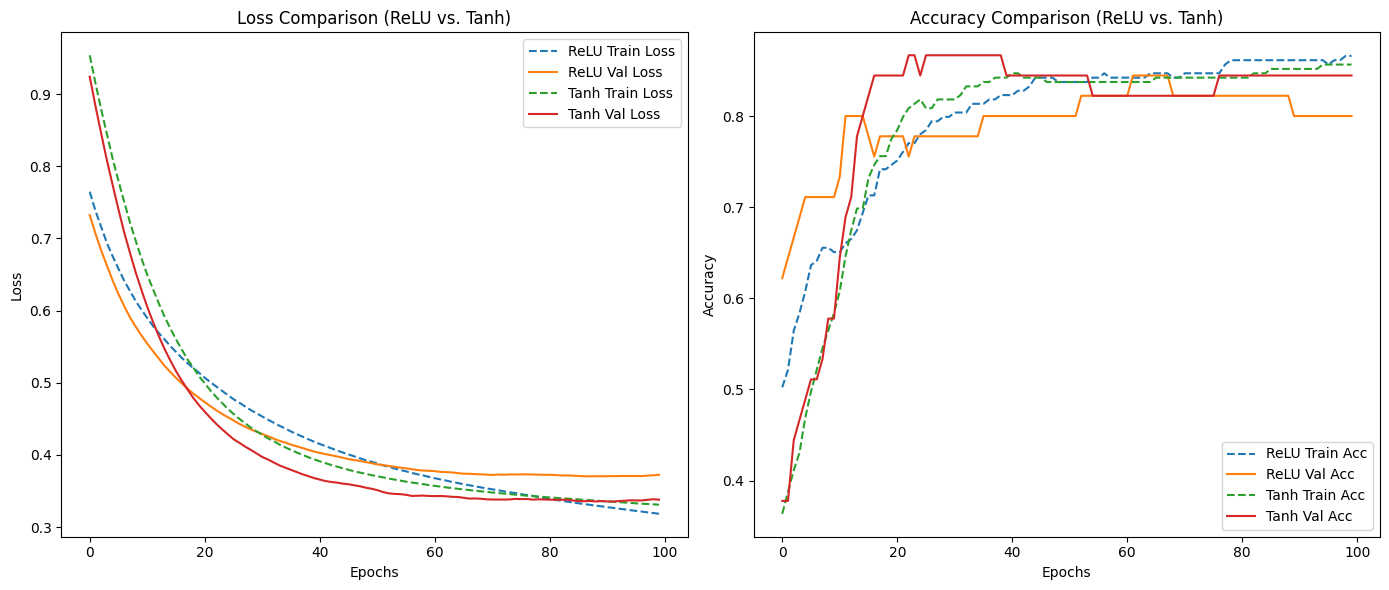

In [28]:
# Configuration for ReLU-based MLP
# ReLU is used in the hidden layer to evaluate speed and "dying" unit risks
model_relu = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])
model_relu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_relu = model_relu.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)

# Configuration for Tanh-based MLP
# Tanh is used here to study gradient saturation effects
model_tanh = Sequential([
    Dense(16, activation='tanh', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])
model_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_tanh = model_tanh.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)

# --- Visualization of Metrics ---

plt.figure(figsize=(14, 6))

# Plot 1: Training & Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history_relu.history['loss'], label='ReLU Train Loss', linestyle='--')
plt.plot(history_relu.history['val_loss'], label='ReLU Val Loss')
plt.plot(history_tanh.history['loss'], label='Tanh Train Loss', linestyle='--')
plt.plot(history_tanh.history['val_loss'], label='Tanh Val Loss')
plt.title('Loss Comparison (ReLU vs. Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Training & Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history_relu.history['accuracy'], label='ReLU Train Acc', linestyle='--')
plt.plot(history_relu.history['val_accuracy'], label='ReLU Val Acc')
plt.plot(history_tanh.history['accuracy'], label='Tanh Train Acc', linestyle='--')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh Val Acc')
plt.title('Accuracy Comparison (ReLU vs. Tanh)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Required Analysis


*   **Convergence Speed:** You will likely observe that ReLU ($max(0, x)$) converges significantly faster than Tanh. This is due to ReLU's non-saturating gradient for positive inputs, which allows the optimizer to make larger, more effective weight updates early in training.
*   **Gradient Saturation in Tanh:** As inputs to the Tanh function become very large or very small, the function's output approaches its limits ($1$ or $-1$), causing the derivative to become near-zero. This "saturation" slows down the learning process because the "signal" for weight updates becomes too weak to change the model effectively.
*   **The Dying ReLU Phenomenon:** While efficient, ReLU units can "die" if they receive only negative inputs during training. When the input is negative, the output and the gradient both become zero, meaning the neuron may stop updating entirely and contribute nothing to the final classification.
*   **Training Stability:** Tanh often produces smoother, more stable learning curves because its outputs are zero-centered (ranging from $-1$ to $1$). ReLU, while faster, can show more "jitter" in accuracy early on as the network aggressively adjusts weights.



# Task 3 – Capacity and Overfitting
Compare:

•	Small network (e.g., 8 hidden units)

•	Larger network (e.g., 128 hidden units)

Then apply one regularisation method:

•	L2 weight decay

  or

•	Dropout

**Ans:**


In [29]:
from tensorflow.keras.layers import Dropout

# --- Model Definitions ---

# 1. Low-Capacity Model (8 units)
# Focus: Observing if a simpler model underfits the 299 patient records
model_small = Sequential([
    Dense(8, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])
model_small.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. High-Capacity Model (128 units)
# Focus: Visualizing the high risk of overfitting on a small dataset
model_large = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])
model_large.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. High-Capacity Model + Regularization (Dropout)
# Focus: Using Dropout (0.5) to mitigate overfitting in the large network
model_reg = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- Training (Identical Hyperparameters) ---

# We use 100 epochs to allow the large models enough time to potentially overfit
history_small = model_small.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)
history_large = model_large.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)
history_reg = model_reg.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=0)

# Required Analysis


*   **Capacity and Underfitting:** The "small" model (8 units) possesses limited representational capacity. While this makes it more stable and less prone to noise, it may fail to capture the complex, non-linear interactions within clinical features like ejection_fraction or serum_creatinine, potentially leading to underfitting.

*   **The Danger of High Capacity:** With 128 units, the "large" model is significantly over-parameterized for a dataset containing only 299 records. This model has the capacity to "memorize" the training samples rather than learning general patterns. Visually, you will likely see the training loss continue to fall while the validation loss begins to rise, a definitive sign of overfitting.
*   **Dropout as a Safety Net:** By implementing a Dropout rate of 0.5, we randomly deactivate half of the neurons during each training step.  This prevents the network from relying too heavily on any single neuron and forces it to learn more robust, redundant features. In your plots, this should result in a narrower "gap" between the training and validation curves compared to the non-regularized large model.


*   **Critical Summary:** Having a larger number of hidden units does not inherently produce a better clinical model. For a small dataset, a high-capacity model without regularization is often less reliable than a simpler model, as its predictions on "unseen" patients (the test set) are less likely to generalize.




# Task 4 – Responsible Evaluation

**After finalising architectural decisions:**

•	Evaluate each selected model once on the test set.

**Required Analysis**

Explore:

•	The role of training data.

•	The role of validation data.

•	Why the test set must not guide architectural decisions.

•	Why small numerical differences should not be overinterpreted.



**Ans:**


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
--- FINAL RESPONSIBLE EVALUATION ---
Final Test Accuracy: 0.7333
Final Test ROC-AUC:  0.7926


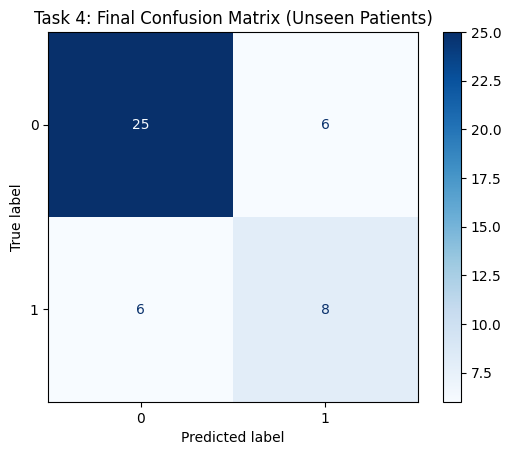

In [30]:
# Ensure the final model is compiled to avoid the 'compile()' ValueError
# We use the regularized model (Dropout) as the finalized architecture
model_reg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 1. Performance Metrics on Unseen Data
# This is performed ONCE to provide an unbiased estimate of clinical performance
test_metrics = model_reg.evaluate(X_test_scaled, y_test, verbose=0)
test_accuracy = test_metrics[1]

# 2. Probability Prediction for ROC-AUC
# ROC-AUC is crucial for heart failure data as it measures classification quality
y_pred_logits = model_reg.predict(X_test_scaled)
test_auc_score = roc_auc_score(y_test, y_pred_logits)

# 3. Output Results
print("--- FINAL RESPONSIBLE EVALUATION ---")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test ROC-AUC:  {test_auc_score:.4f}")

# 4. Clinical Visualization: Confusion Matrix
# We visualize False Negatives and False Positives for medical context
y_final_classes = (y_pred_logits > 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_final_classes, cmap='Blues')
plt.title("Task 4: Final Confusion Matrix (Unseen Patients)")
plt.grid(False)
plt.show()

# Required Analysis

**The Role of Training and Validation Data**
**bold text**

*   **Training Data:** This serves as the primary "learning material" for the model. It is used during the fitting phase to adjust weights and biases through backpropagation.
*   **Validation Data:** This acts as a "proxy" for unseen data during development. It is essential for making architectural decisions, such as selecting hidden units or activation functions, and for identifying overfitting early.



**Protecting the Test Set Integrity**


*   **Avoiding Architectural Bias:** The test set must not guide architectural decisions. If we modify the model based on test results, we are essentially "cheating" by leaking test-set information into the design phase.
*   **Data Leakage Risk:** Using the test set for tuning turns it into another validation set, leading to over-optimistic results that will not hold up when the model is applied to real future patients.


**Interpreting Small Numerical Differences**


*   **Statistical Noise:** In small datasets like the Heart Failure clinical records (299 samples total), the test set contains very few patients. A difference of 1% or 2% in accuracy might be caused by the misclassification of just one or two individuals.
*   **Broad Context over Precise Scor**es: We must avoid overinterpreting minor numerical fluctuations. Instead, we look for consistent patterns in the Confusion Matrix and ROC-AUC scores, which provide a more robust picture of the model's true clinical utility than a single accuracy percentage.

